In [1]:
import matplotlib.pyplot as plt
import numpy as np

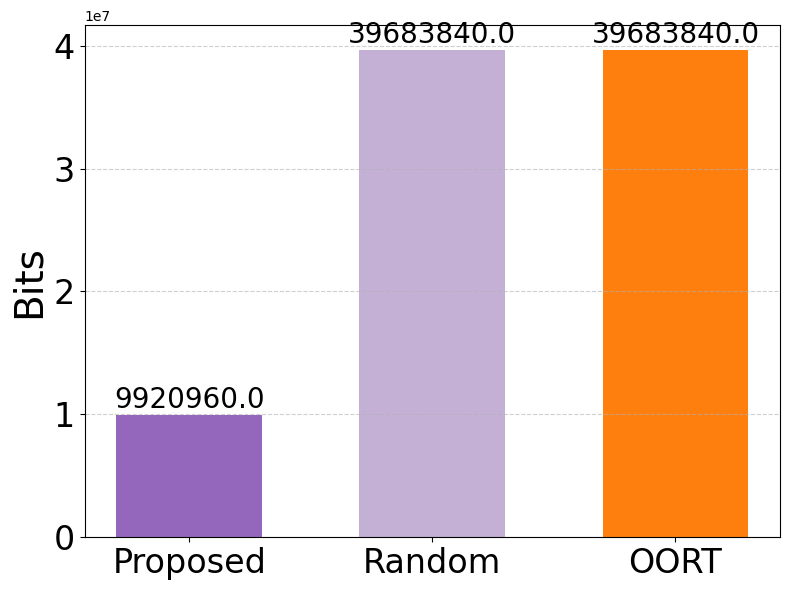

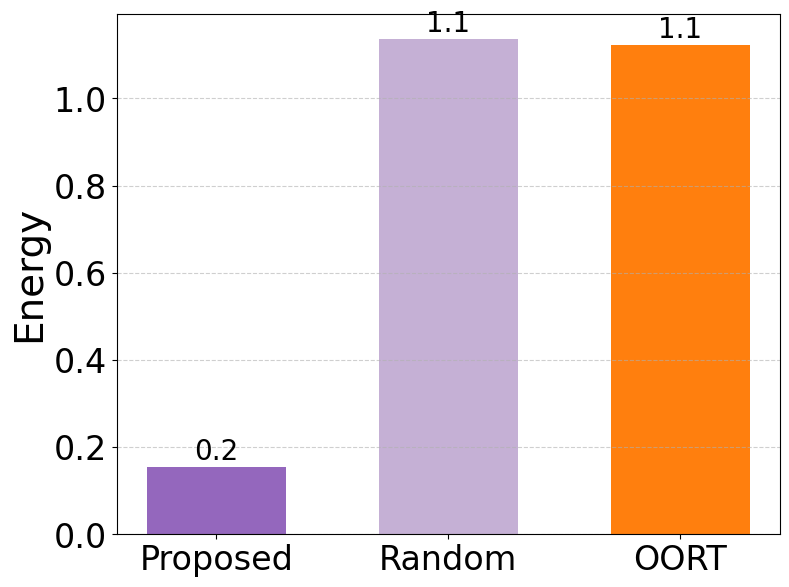

In [2]:
# === Configuration ===
base_dir = "/home/kamrul/Documents/kamrul_files_Linux/OORT/ClusterFed_OORT/results/svhn2/"

svhn_custom_file = "output_svhn_custom_global_dirichlet_Q8_lr0.01_ep1_w0.4.txt"
svhn_random_file = "output_svhn_random_global_dirichlet_lr0.01_ep1.txt"
svhn_oort_file = "output_svhn_oort_global_violation.txt"

# === Metric loader ===
def load_metric(file_name, key):
    data = {}
    with open(base_dir + file_name, "r") as f:
        for line in f:
            parts = line.strip().split("=", 1)
            if len(parts) == 2:
                var_name = parts[0].strip()
                try:
                    data[var_name] = eval(parts[1].strip())
                except Exception as e:
                    print(f"Error parsing {var_name} in {file_name}: {e}")
    return data.get(key, [])

# === Energy calculation from bits (SVHN OORT only) ===
class EnergyCalculator:
    def __init__(self, bandwidth=1e6, power=0.1):
        self.bandwidth = bandwidth
        self.power = power

    def calculate_SNR(self):
        snr_db = np.random.uniform(0, 30)
        return 10 ** (snr_db / 10)

    def calculate_energy(self, bits):
        snr = self.calculate_SNR()
        capacity = self.bandwidth * np.log2(1 + snr)
        transmission_time = bits / capacity
        return self.power * transmission_time

def compute_svhn_oort(file):
    bits = load_metric(file, "grad_size_bits")
    calculator = EnergyCalculator()
    energy = np.mean([calculator.calculate_energy(b) for b in bits])
    avg_bits = np.mean(bits)
    return avg_bits, energy

# === Compute Average Metric for SVHN only ===
def compute_avg(metric_key):
    custom_avg = np.mean(load_metric(svhn_custom_file, f"{metric_key}_custom"))
    random_avg = np.mean(load_metric(svhn_random_file, f"{metric_key}_random"))
    oort_bits, oort_energy = compute_svhn_oort(svhn_oort_file)
    oort_avg = oort_bits if metric_key == 'bits' else oort_energy
    return [custom_avg, random_avg, oort_avg]

# === Plotting Function for SVHN Only ===
def plot_svhn_bar_chart(values, ylabel="Average Value"):
    labels = ["Proposed", "Random", "OORT"]
    colors = ["#9467bd", "#c5b0d5", "#ff7f0e"]

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(labels, values, color=colors, width=0.6)

    label_fontsize = 28
    tick_fontsize = 24
    legend_fontsize = 22

    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points", ha='center', fontsize=20)

    plt.tight_layout()
    plt.show()

# === Plot Results ===
bits_values = compute_avg("bits")
plot_svhn_bar_chart(bits_values, ylabel="Bits")

energy_values = compute_avg("energy")
plot_svhn_bar_chart(energy_values, ylabel="Energy")


In [3]:
def plot_svhn_comparison(bits, energy):
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_style("whitegrid")  # Apply seaborn whitegrid

    methods = ["Proposed", "Random", "OORT"]
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # Plot 1: Average Bits Transmitted
    axes[0].barh(methods, bits, color=colors)
    axes[0].set_xlabel("Average Bits", fontsize=16)
    axes[0].set_title("Average Bits Transmitted", fontsize=18)
    for i, v in enumerate(bits):
        axes[0].text(v + max(bits) * 0.01, i, f"{v:.1f}", va='center', fontsize=14)

    # Plot 2: Average Energy Consumption
    axes[1].barh(methods, energy, color=colors)
    axes[1].set_xlabel("Average Energy (Joules)", fontsize=16)
    axes[1].set_title("Average Energy Consumption", fontsize=18)
    for i, v in enumerate(energy):
        axes[1].text(v + max(energy) * 0.01, i, f"{v:.4f}", va='center', fontsize=14)

    for ax in axes:
        ax.tick_params(labelsize=14)
        ax.grid(True, axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


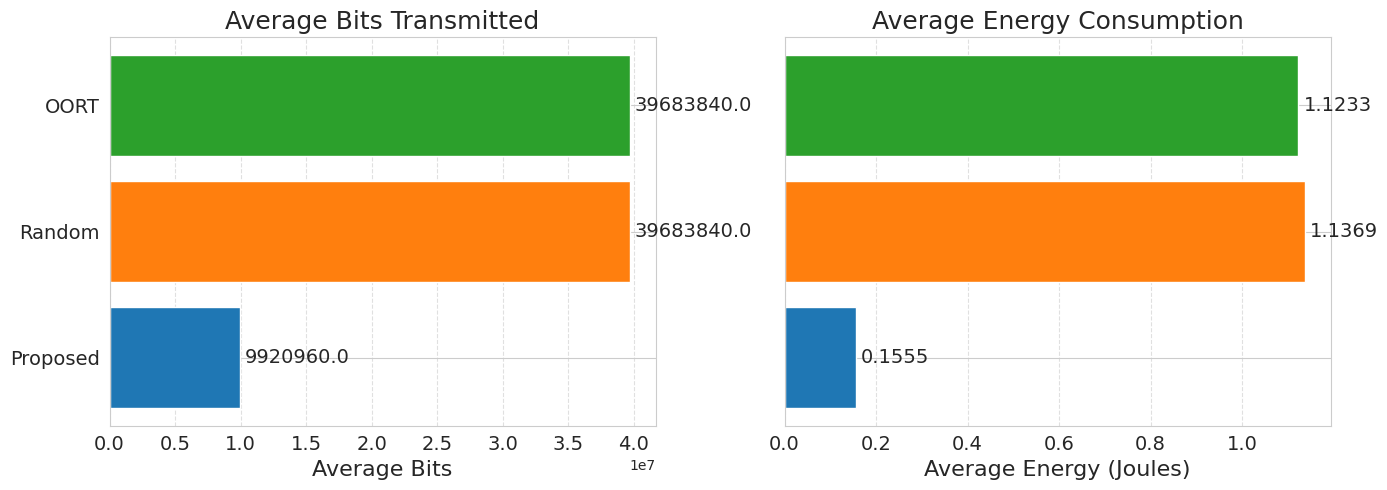

In [4]:
bits_values = compute_avg("bits")
energy_values = compute_avg("energy")
plot_svhn_comparison(bits_values, energy_values)

In [5]:
def plot_tradeoff(bits, energy):
    import matplotlib.pyplot as plt

    methods = ["AdRo-FL", "Random", "Oort"]
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    # Manual annotation offsets (x, y)
    annotation_offsets = {
        "AdRo-FL": (20, 10),
        "Random": (20, -40),
        "Oort": (-100, 20),
    }

    fig, ax = plt.subplots(figsize=(6, 4.5))  # Smaller plot
    fig.set_dpi(300)  # Increase display resolution

    for i, method in enumerate(methods):
        x = bits[i]
        y = energy[i]

        # Larger bubbles
        ax.scatter(x, y, label=method, color=colors[i], s=500, edgecolor='black', zorder=3)

        # Dashed guides
        ax.axhline(y, color=colors[i], linestyle='--', linewidth=1, alpha=0.4)
        ax.axvline(x, color=colors[i], linestyle='--', linewidth=1, alpha=0.4)

        # Annotation with callout
        dx, dy = annotation_offsets[method]
        ax.annotate(
            f"{method}\n({x:.1f}, {y:.4f})",
            xy=(x, y),
            xytext=(dx, dy),
            textcoords='offset points',
            fontsize=10,
            ha='left',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[i], lw=1),
            arrowprops=dict(arrowstyle="->", color=colors[i], lw=1.5, alpha=0.7)
        )

    ax.set_xlabel("Average Bits Transmitted", fontsize=12)
    ax.set_ylabel("Average Energy (joule)", fontsize=12)
    #ax.set_title("SVHN Communication Efficiency", fontsize=13)

    ax.grid(True, linestyle="--", alpha=0.6)
    ax.tick_params(labelsize=10)

    # Adjust spacing
    x_margin = (max(bits) - min(bits)) * 0.3
    y_margin = (max(energy) - min(energy)) * 0.3
    ax.set_xlim(min(bits) - x_margin, max(bits) + x_margin)
    ax.set_ylim(min(energy) - y_margin, max(energy) + y_margin)

    plt.tight_layout()
    plt.show()


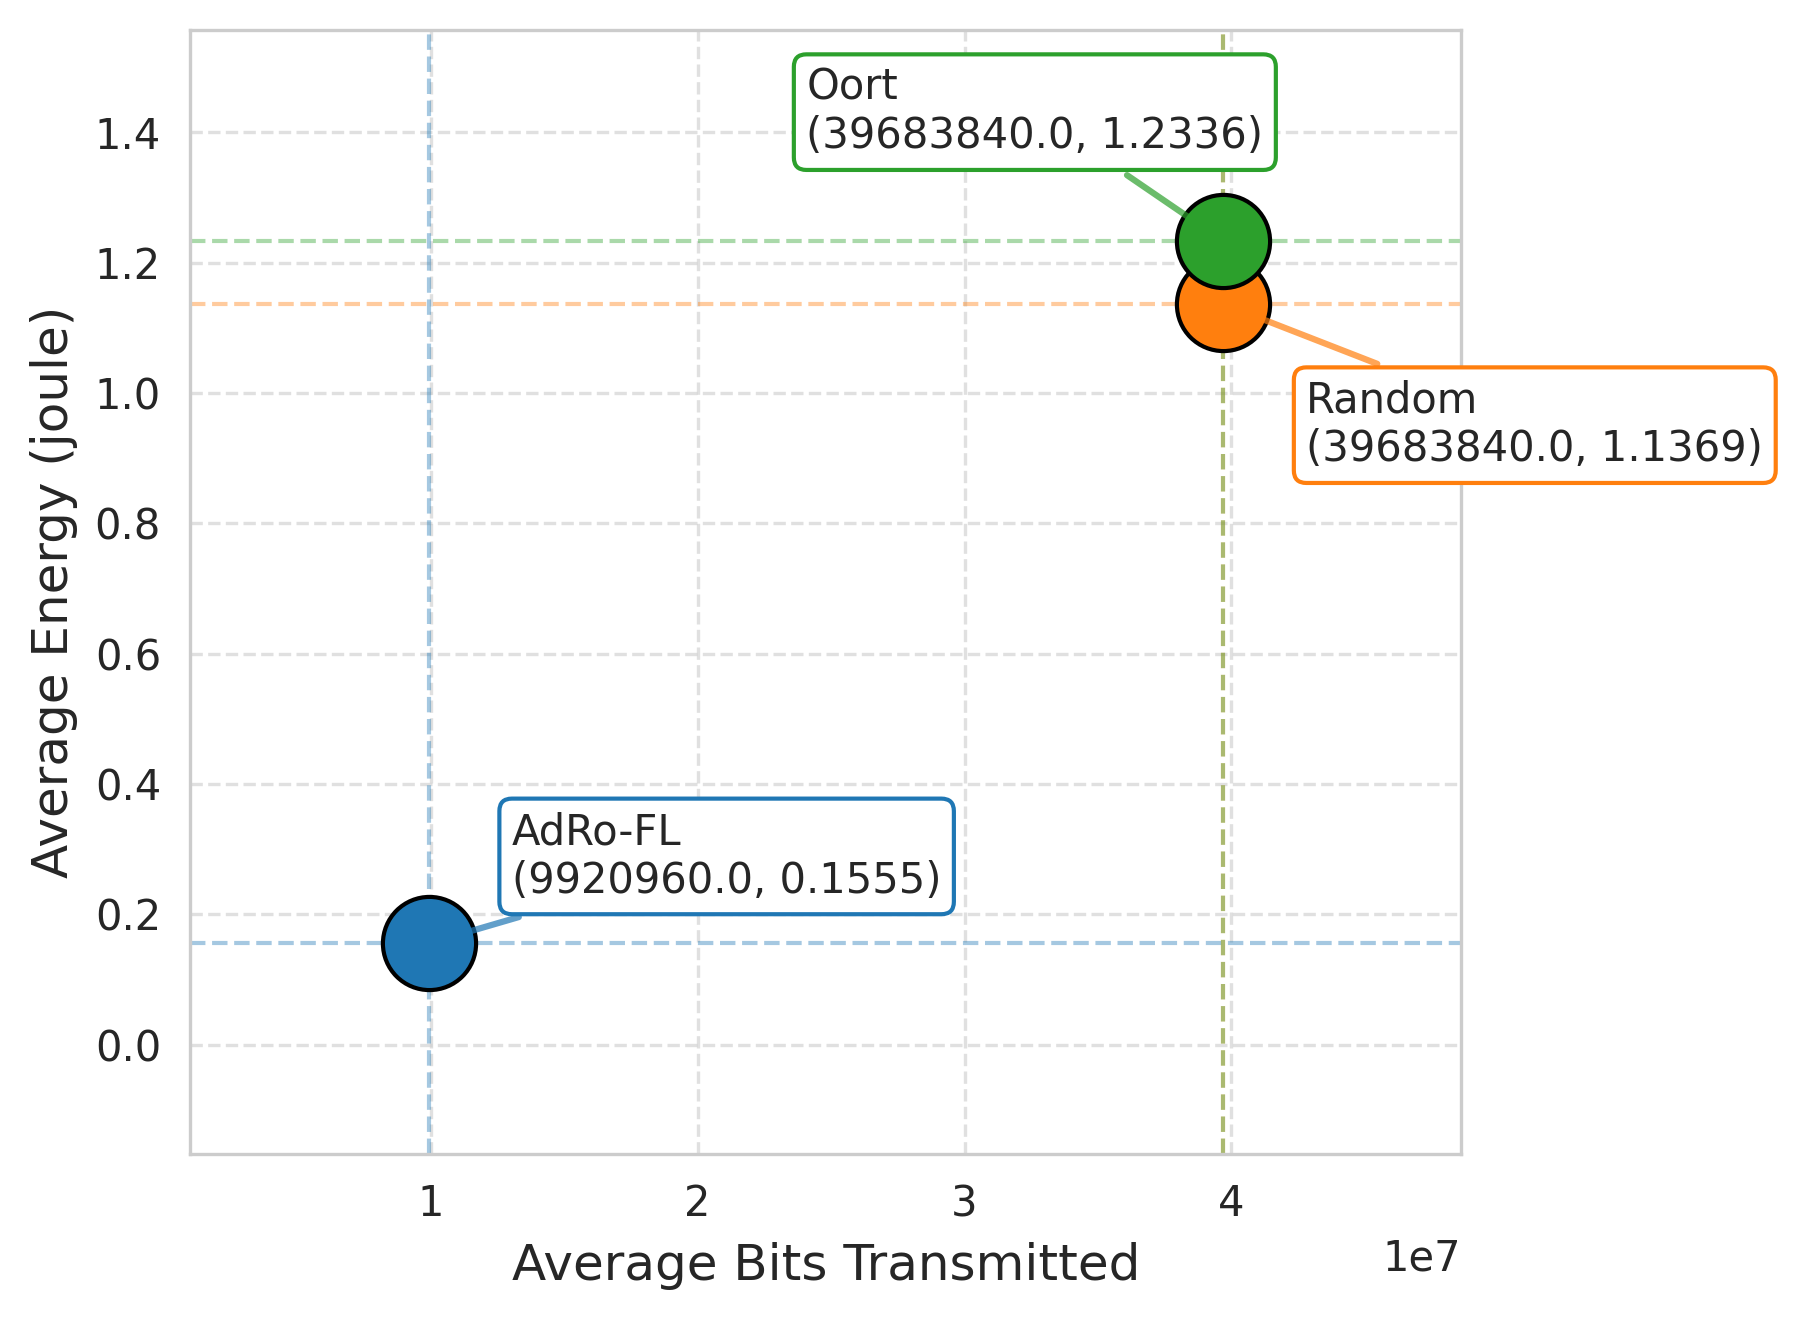

In [6]:
bits = compute_avg("bits")
energy = compute_avg("energy")
plot_tradeoff(bits, energy)
